In [ ]:
import zipfile
import os

zip_path = "archive.zip"     # jo zip file dikhe uska exact naam
extract_path = "dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("ZIP Extracted Successfully")
print(os.listdir("dataset"))

In [15]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split,learning_curve
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc
)

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from skimage.feature import (
    hog,
    local_binary_pattern
)

from skimage import exposure

In [16]:
base_path = "/kaggle/input/datasets/anthonytherrien/dog-vs-cat/animals"

IMG_SIZE = 256

In [17]:
def preprocess_image(img):
    img = cv2.resize(img, (128, 128))

    img = cv2.medianBlur(img, 5)

    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    gray = cv2.equalizeHist(gray)

    return img, hsv, gray

In [42]:
from skimage.feature import local_binary_pattern, hog

def extract_features(img, hsv, gray):
    features = []
    
    # 1. HSV HISTOGRAM
    hist = cv2.calcHist([hsv],[0],None,[32],[0,180])
    hist = hist.astype("float32")
    hist /= (hist.sum() + 1e-6)

    features.extend(hist.flatten())

    # 2. LBP FEATURES
    lbp = local_binary_pattern(gray,P=8,R=1,method='uniform')
    lbp_hist, _ = np.histogram(lbp.ravel(),bins=10,range=(0,10))
    lbp_hist = lbp_hist.astype("float32")
    lbp_hist /= (lbp_hist.sum() + 1e-6)

    features.extend(lbp_hist)

    # 3. SHAPE FEATURES
    edges = cv2.Canny(gray, 100, 200)

    contours, _ = cv2.findContours(edges,cv2.RETR_EXTERNAL,cv2.CHAIN_APPROX_SIMPLE)

    area = sum(cv2.contourArea(c) for c in contours)

    perimeter = sum(cv2.arcLength(c, True) for c in contours )

    area = np.clip(area, 0, 1e5)

    perimeter = np.clip(perimeter, 0, 1e4)

    circularity = (4 * np.pi * area) / (perimeter**2 + 1e-6)

    features.extend([area,perimeter,circularity])

    # 4. HOG FEATURES
    hog_features, hog_image = hog(gray,orientations=8,pixels_per_cell=(16,16),cells_per_block=(2,2),visualize=True)

    features.extend(hog_features[:100])

    return np.array(features,dtype=np.float32)

In [43]:
# IMAGE AUGMENTATION
def augment_image(img):
    augmented = []
    
    # ORIGINAL
    augmented.append(img)

    # FLIP
    flip = cv2.flip(img, 1)
    augmented.append(flip)

    # BRIGHTNESS
    bright = cv2.convertScaleAbs(img,alpha=1,beta=50)
    augmented.append(bright)

    # CONTRAST

    contrast = cv2.convertScaleAbs(img,alpha=1.5,beta=0)
    augmented.append(contrast)
    
    # ROTATION
    h, w = img.shape[:2]
    matrix = cv2.getRotationMatrix2D((w//2, h//2),45,1)

    rotated = cv2.warpAffine(img,matrix,(w, h))
    augmented.append(rotated)

    # SPATIAL FILTERING
    filtered = cv2.bilateralFilter(img,9,75,75)
    augmented.append(filtered)

    return augmented

In [44]:
# LOAD DATASET WITH PREPROCESSING + AUGMENTATION
def load_dataset(base_path):
    X = []
    y = []

    class_map = {"cat": 0,"dog": 1}

    classes = os.listdir(base_path)

    print("Classes :", classes)

    for cls, label in class_map.items():

        folder = os.path.join(
            base_path,
            cls
        )

        if not os.path.isdir(folder):
            continue

        print("\nReading :", cls)

        for file in os.listdir(folder):

            img_path = os.path.join(
                folder,
                file
            )

            try:

                img = cv2.imread(img_path)

                # CORRUPTED IMAGE CHECK

                if img is None:

                    print(
                        "Corrupted Image :",
                        img_path
                    )

                    continue

                # AUGMENTATION

                augmented_images = augment_image(img)
                for aug_img in augmented_images:
                    
                    # PREPROCESSING
                    img_p, hsv, gray = preprocess_image(
                        aug_img
                    )

                    # FEATURE EXTRACTION

                    features = extract_features(img_p,hsv,gray)
                    X.append(features)
                    y.append(label)

            except:

                continue

    return np.array(X), np.array(y)

In [45]:
X, y = load_dataset("/kaggle/input/datasets/anthonytherrien/dog-vs-cat/animals")
mask = np.isfinite(X).all(axis=1)
X = X[mask]
y = y[mask]

# X = np.array(X)
# y = np.array(y)
# print("\nTotal Samples :", len(X))

Classes : ['dog', 'cat']

Reading : cat

Reading : dog


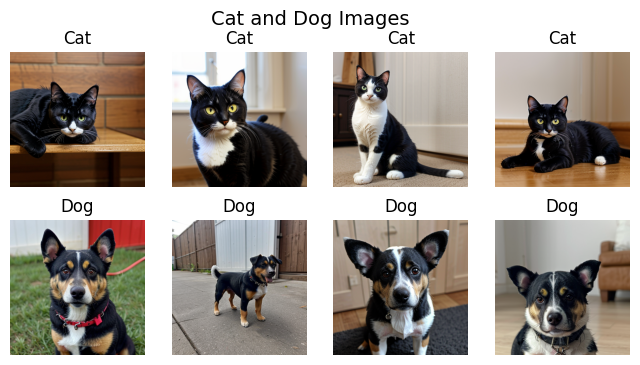

In [25]:
def show_sample_images(base_path, samples=3):
    classes = ["cat", "dog"]

    plt.figure(figsize=(8, 4))

    idx = 1
    for cls in classes:
        folder = os.path.join(base_path, cls)
        images = os.listdir(folder)[:samples]

        for img_name in images:
            img_path = os.path.join(folder, img_name)
            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            plt.subplot(2, samples, idx)
            plt.imshow(img)
            plt.title(cls.capitalize())
            plt.axis("off")
            idx += 1

    plt.suptitle("Cat and Dog Images", fontsize=14)
    plt.show()
show_sample_images("/kaggle/input/datasets/anthonytherrien/dog-vs-cat/animals", samples=4)

In [26]:
def show_preprocessing_demo(img_path):
    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    img, hsv, gray = preprocess_image(img)
    edges = cv2.Canny(gray, 100, 200)

    plt.figure(figsize=(10, 6))

    plt.subplot(1, 4, 1)
    plt.imshow(img_rgb)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1, 4, 2)
    plt.imshow(gray, cmap="gray")
    plt.title("Grayscale + Equalized")
    plt.axis("off")

    plt.subplot(1, 4, 3)
    plt.imshow(hsv[:,:,0], cmap="hsv")
    plt.title("HSV (Hue Channel)")
    plt.axis("off")

    plt.subplot(1, 4, 4)
    plt.imshow(edges, cmap="gray")
    plt.title("Edge Detection (Canny)")
    plt.axis("off")

    plt.tight_layout()
    plt.show()
path = "/kaggle/input/datasets/anthonytherrien/dog-vs-cat/animals/cat"

print(os.listdir(path)[:10])

['00246-200124556.png', '00102-200124412.png', '00034-200124344.png', '00350-200124660.png', '00343-200124653.png', '00119-200124429.png', '00396-200124706.png', '00494-200124804.png', '00397-200124707.png', '00025-200124335.png']


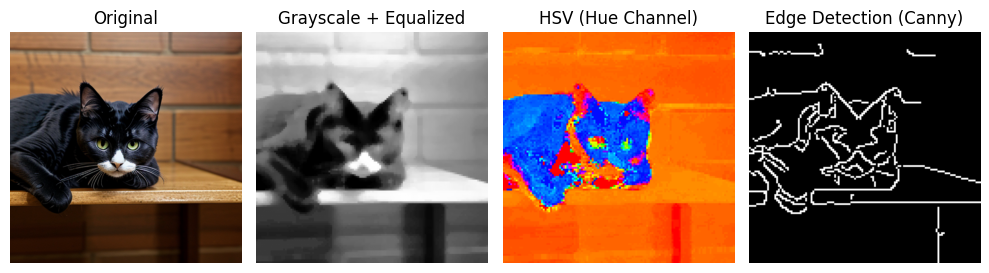

In [47]:
show_preprocessing_demo("/kaggle/input/datasets/anthonytherrien/dog-vs-cat/animals/cat/00246-200124556.png")

In [48]:
path = "/kaggle/input/datasets/anthonytherrien/dog-vs-cat/animals/dog"

print(os.listdir(path)[:10])

['00985-127787239.png', '00667-3846168829.png', '00891-3846169053.png', '00528-3846168690.png', '00689-3846168851.png', '00593-3846168755.png', '00894-3846169056.png', '00622-3846168784.png', '00907-3846169069.png', '00983-127787237.png']


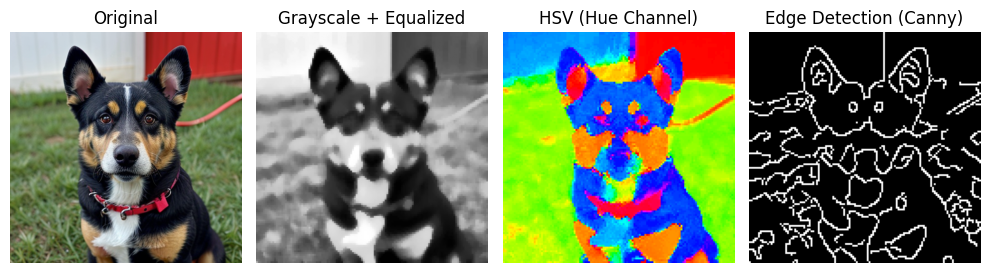

In [49]:
show_preprocessing_demo("/kaggle/input/datasets/anthonytherrien/dog-vs-cat/animals/dog/00985-127787239.png")

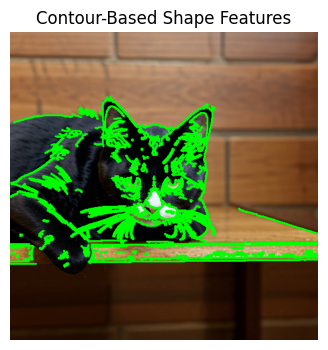

In [50]:
def show_contours(img_path):
    img = cv2.imread(img_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    edges = cv2.Canny(gray, 100, 200)
    contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    contour_img = img.copy()
    cv2.drawContours(contour_img, contours, -1, (0, 255, 0), 2)

    plt.figure(figsize=(4, 4))
    plt.imshow(cv2.cvtColor(contour_img, cv2.COLOR_BGR2RGB))
    plt.title("Contour-Based Shape Features")
    plt.axis("off")
    plt.show()
show_contours("/kaggle/input/datasets/anthonytherrien/dog-vs-cat/animals/cat/00246-200124556.png")

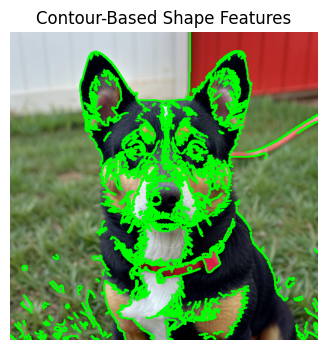

In [51]:
show_contours("/kaggle/input/datasets/anthonytherrien/dog-vs-cat/animals/dog/00985-127787239.png")

In [52]:
img=cv2.imread("/kaggle/input/datasets/anthonytherrien/dog-vs-cat/animals/cat/00246-200124556.png")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
sift = cv2.SIFT_create()
keypoints, descriptors = sift.detectAndCompute(gray, None)
sift_img = cv2.drawKeypoints(
    img, keypoints, None,
    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
)

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

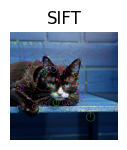

In [53]:
plt.subplot(3,4,12); plt.imshow(sift_img); plt.title("SIFT"); plt.axis('off')

In [54]:
X_train, X_test, y_train, y_test = train_test_split( X,y,test_size=0.2,random_state=42,stratify=y)

In [55]:
# FEATURE SCALING
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [56]:
models = {

    "SVM": SVC(
        C=10,
        kernel='rbf',
        gamma='scale',
        probability=True
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=150,
        max_depth=10,
        random_state=42
    ),

    "KNN": KNeighborsClassifier(
        n_neighbors=5,
        weights='distance'
    )

}

In [57]:
best_model = None
best_accuracy = 0
best_name = ""

# TRAINING

for name, model in models.items():

    print("\nTraining :", name)

    model.fit(X_train,y_train)

    pred = model.predict(X_test)

    acc = accuracy_score(y_test,pred)

    print(name, "Accuracy :", acc)

    if acc > best_accuracy:

        best_accuracy = acc
        best_model = model
        best_name = name


Training : SVM
SVM Accuracy : 0.9616666666666667

Training : Random Forest
Random Forest Accuracy : 0.9233333333333333

Training : KNN
KNN Accuracy : 0.9216666666666666


In [58]:
# FINAL RESULT
print("\nBest Model :", best_name)

print("Best Accuracy :", best_accuracy)

y_pred = best_model.predict(X_test)

print("\nClassification Report\n")

print(classification_report(y_test,y_pred))


Best Model : SVM
Best Accuracy : 0.9616666666666667

Classification Report

              precision    recall  f1-score   support

           0       0.96      0.96      0.96       600
           1       0.96      0.96      0.96       600

    accuracy                           0.96      1200
   macro avg       0.96      0.96      0.96      1200
weighted avg       0.96      0.96      0.96      1200



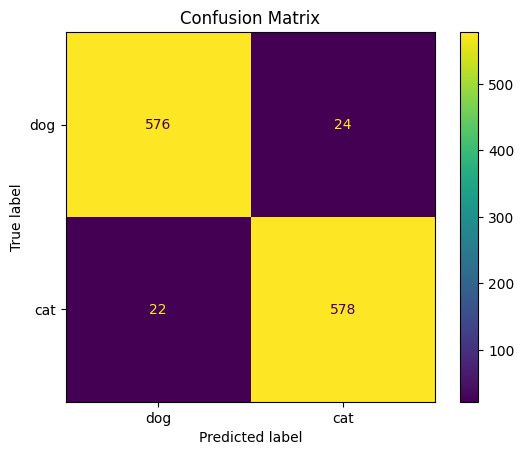

In [59]:
cm = confusion_matrix(y_test,y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=classes)

disp.plot()

plt.title("Confusion Matrix")

plt.show()

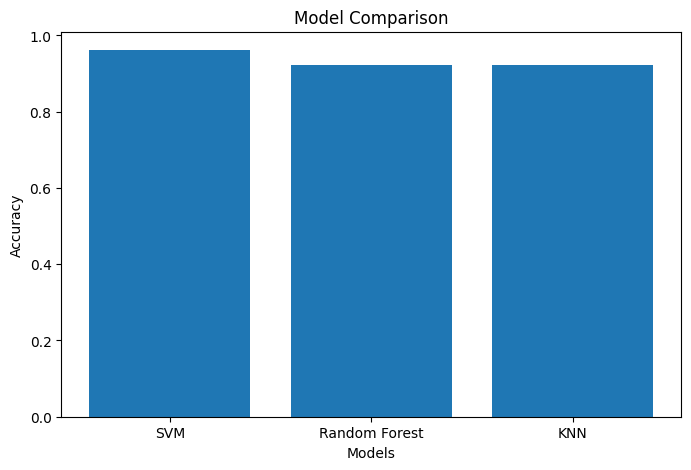

In [60]:
model_names = []

accuracies = []

for name, model in models.items():

    pred = model.predict(X_test)

    acc = accuracy_score(
        y_test,
        pred
    )

    model_names.append(name)

    accuracies.append(acc)

plt.figure(figsize=(8,5))

plt.bar(model_names,accuracies)

plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Comparison")
plt.show()

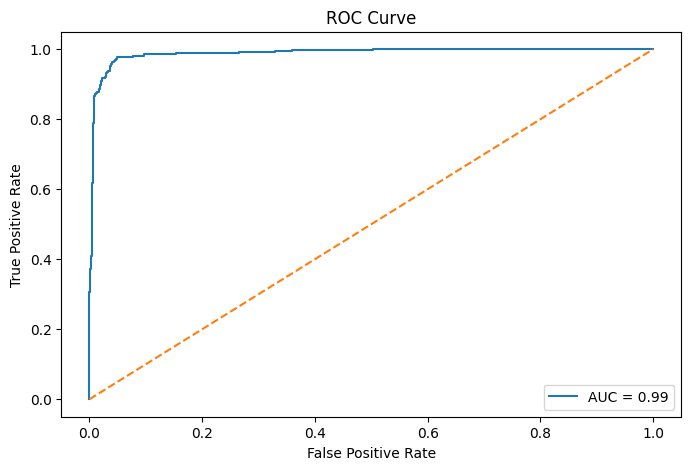

In [61]:
if len(classes) == 2:

    y_score = best_model.predict_proba(X_test)[:,1]

    fpr, tpr, thresholds = roc_curve(y_test,y_score)

    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(8,5))
    plt.plot(fpr,tpr, label=f"AUC = {roc_auc:.2f}")

    plt.plot([0,1],[0,1],linestyle='--')

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend()
    plt.show()

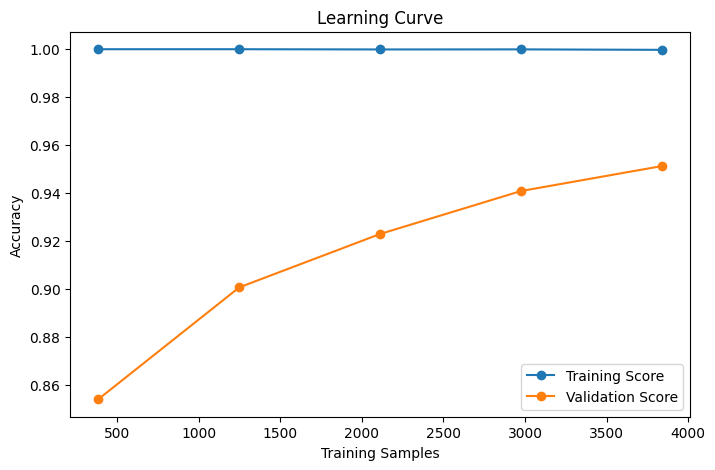

In [62]:
# LEARNING CURVE

train_sizes, train_scores, test_scores = learning_curve(best_model,X_train,y_train,cv=5,scoring='accuracy')

train_mean = np.mean(train_scores,axis=1)

test_mean = np.mean(test_scores,axis=1)

plt.figure(figsize=(8,5))

plt.plot(train_sizes,train_mean,marker='o',label='Training Score')

plt.plot(train_sizes,test_mean,marker='o',label='Validation Score')

plt.xlabel("Training Samples")
plt.ylabel("Accuracy")
plt.title("Learning Curve")
plt.legend()
plt.show()